# CELL 1 — Setup: Mount Drive + Install + Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# soundfile = librosa ka backend, .wav files padhne ke liye zaroori
# librosa akela install karne se soundfile miss ho sakta hai colab mein
!pip install librosa soundfile -q

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings

# librosa internally kuch deprecated function warnings deta hai
# woh hamare kaam ki nahi hain, isliye hide kar rahe hain
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('dark_background')
sns.set_palette('husl')

print("✅ Setup complete")
print(f"librosa version : {librosa.__version__}")

✅ Setup complete
librosa version : 0.11.0


# CELL 2 — Set Path + Auto-Detect Dataset Structure

In [ ]:
# ════════════════════════════════════════════════════
# CELL 2 — Config at one place
# Problem tha: path 5 alag cells mein hardcoded tha
# Fix: sab kuch ek CONFIG dict mein — ek jagah change karo, sab jagah update
# ════════════════════════════════════════════════════

CONFIG = {
    'dataset_path' : '/content/drive/MyDrive/Baby Cry Sence Dataset',
    'csv_save_path': '/content/drive/MyDrive/Baby Cry Sence Dataset/features_matrix.csv',
    'models_dir'   : '/content/drive/MyDrive/Baby Cry Sence Dataset/models/',
    'sample_rate'  : 22050,   # sabhi files is rate pe resample hongi — consistency ke liye
    'min_duration' : 1.0,     # pehle 0.5 tha — 0.5 sec mein MFCC reliable nahi hota
                              # 1.0 sec minimum rakha taaki enough frames milein
    'n_mfcc'       : 20,      # 20 MFCC coefficients — audio ML mein standard choice
}

DATASET_PATH = CONFIG['dataset_path']

if not os.path.exists(DATASET_PATH):
    print(f"❌ Path not found: {DATASET_PATH}")
else:
    print(f"✅ Dataset found: {DATASET_PATH}")

print("\n📁 Folder contents:")
for item in sorted(os.listdir(DATASET_PATH)):
    item_path = os.path.join(DATASET_PATH, item)
    if os.path.isdir(item_path):
        # endswith('.wav') — sirf audio files count karo, hidden files ya .DS_Store nahi
        n = len([f for f in os.listdir(item_path) if f.endswith('.wav')])
        print(f"  📂 {item:<15} → {n} .wav files")
    else:
        print(f"  📄 {item}")

# isdir() — sirf folders ko classes maano, loose files ko nahi
CLASS_FOLDERS = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"\n🏷️  Classes detected : {CLASS_FOLDERS}")
print(f"📊 Total classes    : {len(CLASS_FOLDERS)}")

✅ Dataset found: /content/drive/MyDrive/Baby Cry Sence Dataset

📁 Folder contents:
  📄 .DS_Store
  📂 belly_pain      → 16 .wav files
  📂 burping         → 18 .wav files
  📂 cold_hot        → 7 .wav files
  📂 discomfort      → 30 .wav files
  📄 features_matrix.csv
  📂 hungry          → 382 .wav files
  📂 lonely          → 11 .wav files
  📂 models          → 0 .wav files
  📂 scared          → 20 .wav files
  📂 tired           → 28 .wav files

🏷️  Classes detected : ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'models', 'scared', 'tired']
📊 Total classes    : 9


# CELL 3 — Build a DataFrame with all file paths and labels
# This is the FOUNDATION of EDA — we need a table first

In [ ]:
# ════════════════════════════════════════════════════
# CELL 3 — Build master DataFrame
# Koi nayi fix nahi yahan — yeh theek tha
# Bas CONFIG se path le rahe hain ab hardcode nahi
# ════════════════════════════════════════════════════

records = []

for label in CLASS_FOLDERS:
    class_path = os.path.join(DATASET_PATH, label)
    for filename in os.listdir(class_path):
        if filename.endswith('.wav'):
            records.append({
                'filename' : filename,
                'filepath' : os.path.join(class_path, filename),
                'label'    : label
            })

df = pd.DataFrame(records)

print(f"Total files : {len(df)}")
print(f"Classes     : {df['label'].nunique()}")
print(f"\nFiles per class:")
print(df['label'].value_counts().to_string())
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")

Total files : 512
Classes     : 8

Files per class:
label
hungry        382
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7

Missing values:
filename    0
filepath    0
label       0


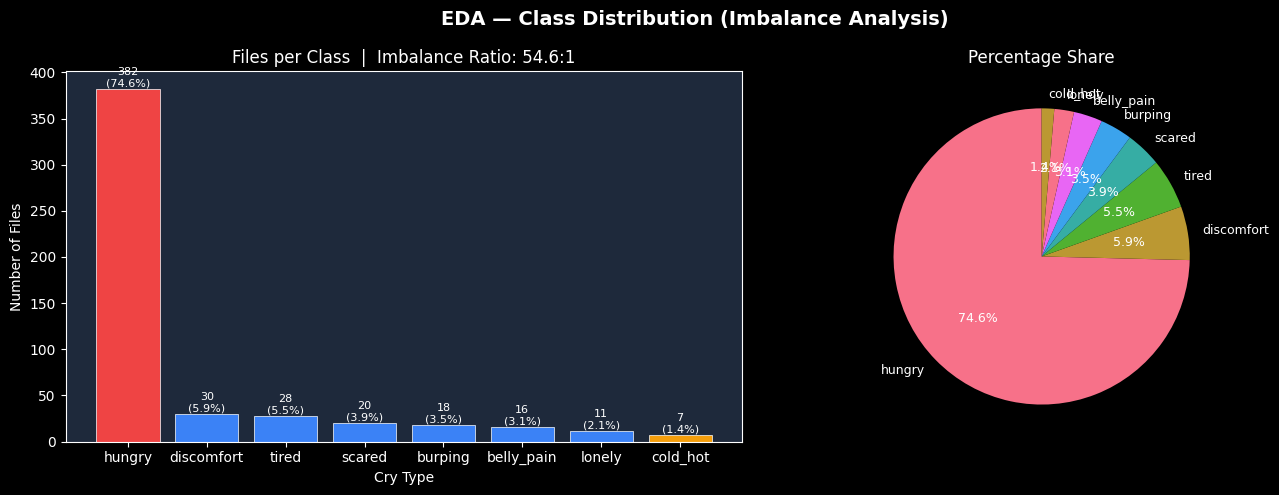


📊 IMBALANCE SEVERITY REPORT
─────────────────────────────────────────────
  hungry      :  382 files ( 74.6%)  ████████████████████████████████████████████████████████████████████████████
  discomfort  :   30 files (  5.9%)  ██████
  tired       :   28 files (  5.5%)  █████
  scared      :   20 files (  3.9%)  ████
  burping     :   18 files (  3.5%)  ███
  belly_pain  :   16 files (  3.1%)  ███
  lonely      :   11 files (  2.1%)  ██
  cold_hot    :    7 files (  1.4%)  █

  Imbalance ratio : 54.6:1
  Severity        : 🔴 EXTREME (>20:1)
  ⚠️  class_weight='balanced' ALONE is not enough at this ratio
  → Need: undersampling majority OR oversampling minority (SMOTE)


In [ ]:
# ════════════════════════════════════════════════════
# CELL 4 — Class distribution visualization
# Problem tha: imbalance ratio 54:1 tha, plot tha lekin
# koi quantitative warning nahi thi ki yeh kitna serious hai
# Fix: severity levels add kiye — mentor jaise batana chahiye
# ════════════════════════════════════════════════════

counts = df['label'].value_counts().reset_index()
counts.columns = ['label', 'count']
total = counts['count'].sum()
counts['percent'] = (counts['count'] / total * 100).round(1)

# imbalance ratio = sabse zyada wali class / sabse kam wali class
# yeh single number batata hai kitna skewed hai dataset
imbalance_ratio = counts['count'].max() / counts['count'].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Class Distribution (Imbalance Analysis)',
             fontsize=14, fontweight='bold')

# ── Bar chart ──────────────────────────────────────
colors = ['#ef4444' if c == counts['count'].max()   # majority = red (danger)
          else '#f59e0b' if c == counts['count'].min()  # minority = amber (warning)
          else '#3b82f6'                                 # rest = blue
          for c in counts['count']]

bars = axes[0].bar(counts['label'], counts['count'],
                   color=colors, edgecolor='white', linewidth=0.5)

for bar, row in zip(bars, counts.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{row.count}\n({row.percent}%)",
                 ha='center', va='bottom', fontsize=8, color='white')

axes[0].set_title(f'Files per Class  |  Imbalance Ratio: {imbalance_ratio:.1f}:1')
axes[0].set_xlabel('Cry Type')
axes[0].set_ylabel('Number of Files')
axes[0].set_facecolor('#1e293b')

# ── Pie chart ──────────────────────────────────────
axes[1].pie(counts['count'], labels=counts['label'],
            autopct='%1.1f%%',
            textprops={'color': 'white', 'fontsize': 9},
            startangle=90)
axes[1].set_title('Percentage Share')
axes[1].set_facecolor('#1e293b')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Severity assessment ─────────────────────────────
# yeh classification maine khud define ki hai industry practice se:
# <3:1   → acceptable, minor adjustments needed
# 3-10:1 → moderate, class_weight + stratify zaroori
# >10:1  → severe, class_weight alone kaafi nahi, resampling chahiye
# >20:1  → extreme, minority class predictions unreliable hongi
print("\n📊 IMBALANCE SEVERITY REPORT")
print("─" * 45)
for _, row in counts.iterrows():
    bar = '█' * int(row['count'] / 5)
    print(f"  {row['label']:<12}: {row['count']:>4} files ({row['percent']:>5}%)  {bar}")

print(f"\n  Imbalance ratio : {imbalance_ratio:.1f}:1")

if imbalance_ratio > 20:
    # 54:1 is extreme — class_weight alone will NOT fix this
    # model will still be biased toward 'hungry'
    # we need oversampling or undersampling — covered in model training cells
    print("  Severity        : 🔴 EXTREME (>20:1)")
    print("  ⚠️  class_weight='balanced' ALONE is not enough at this ratio")
    print("  → Need: undersampling majority OR oversampling minority (SMOTE)")
elif imbalance_ratio > 10:
    print("  Severity        : 🟠 SEVERE (>10:1)")
    print("  → Need: class_weight='balanced' + stratified CV + F1 not accuracy")
elif imbalance_ratio > 3:
    print("  Severity        : 🟡 MODERATE (>3:1)")
    print("  → Need: class_weight='balanced' + stratified CV")
else:
    print("  Severity        : 🟢 ACCEPTABLE (<3:1)")

⏳ Analysing all audio files — silence detection included...
   Min duration threshold : 1.0 sec

🎚️  Unique sampling rates found: [ 8000 44100]
   ⚠️  Mixed sampling rates — will standardize to 22050 Hz during feature extraction

📊 Duration Stats (AFTER silence trimming):
            raw_duration  trimmed_duration  silence_percent
label                                                      
belly_pain          6.95              6.48             6.78
burping             7.08              6.51             7.84
cold_hot            6.86              6.40             6.61
discomfort          6.92              6.61             4.55
hungry              6.92              6.31             8.82
lonely              6.87              6.07            11.74
scared              7.27              6.12            15.94
tired               6.91              6.33             8.40

⚠️  Files where >50% is silence : 11
   These files ke features unreliable honge even after trimming

🗑️  Files too short afte

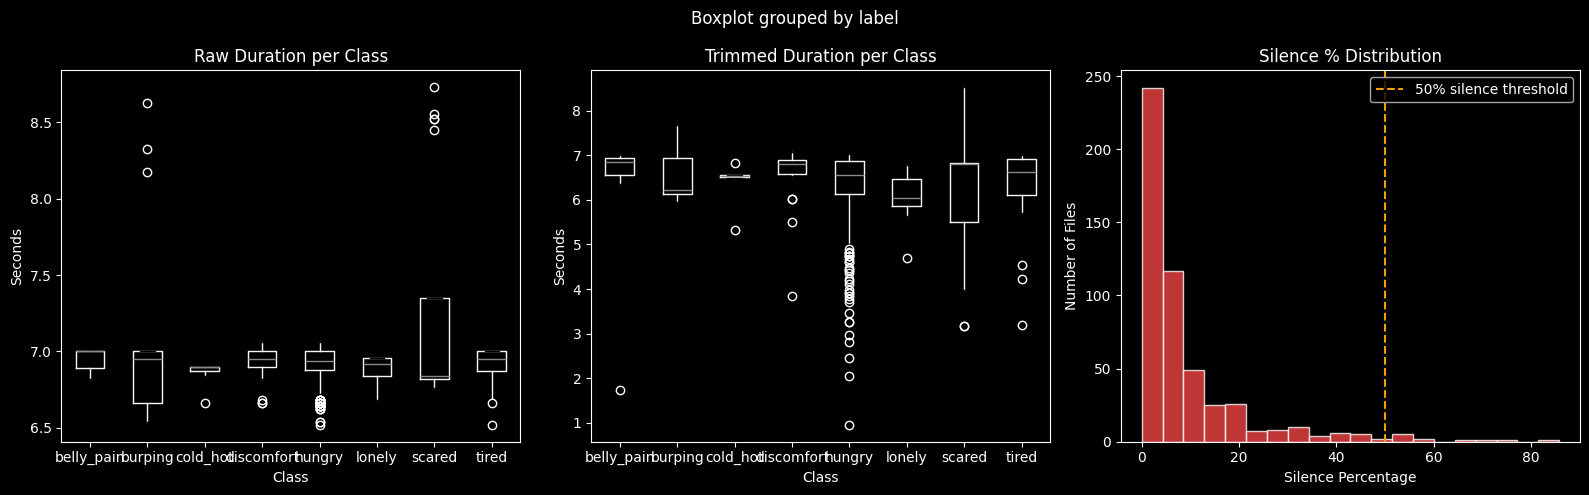

In [ ]:
# ════════════════════════════════════════════════════
# CELL 5 — Duration analysis + silence detection
#
# Problem 1 tha: silence check nahi tha
# librosa.effects.trim() silence hatata hai file ke
# start aur end se — phir actual audio duration check karte hain
#
# Problem 2 tha: min_duration 0.5 sec tha
# 0.5 sec mein sirf ~11 MFCC frames bante hain — bahut kam
# 1.0 sec minimum rakha — ~22 frames — zyada reliable
#
# Problem 3 tha: sampling rate consistency check nahi tha
# agar files alag-alag sr pe hain toh MFCC values
# comparable nahi hongi — isliye sr=None se load karke
# original sr check karte hain pehle
# ════════════════════════════════════════════════════

print("⏳ Analysing all audio files — silence detection included...")
print(f"   Min duration threshold : {CONFIG['min_duration']} sec\n")

duration_records = []
error_files      = []

for idx, row in df.iterrows():
    try:
        # sr=None — original sampling rate mein load karo
        # PEHLE original sr check karna hai consistency ke liye
        # baad mein feature extraction mein hum resample karenge
        y_raw, sr_original = librosa.load(row['filepath'], sr=None)

        # ── Silence trimming ──────────────────────────
        # top_db=30 — 30 dB se neeche ki awaaz ko silence maano
        # yeh threshold industry mein common hai baby audio ke liye
        # zyada chhota value (20) → zyada aggressive trimming → useful signal bhi cut ho sakta hai
        # zyada bada value (40)  → silence bhi reh jaata hai → features contaminate hoti hain
        y_trimmed, _ = librosa.effects.trim(y_raw, top_db=30)

        raw_duration     = len(y_raw)     / sr_original
        trimmed_duration = len(y_trimmed) / sr_original

        # silence removed = raw - trimmed
        silence_sec = raw_duration - trimmed_duration

        duration_records.append({
            'filename'        : row['filename'],
            'label'           : row['label'],
            'raw_duration'    : round(raw_duration, 3),
            'trimmed_duration': round(trimmed_duration, 3),
            'silence_removed' : round(silence_sec, 3),
            'silence_percent' : round((silence_sec / raw_duration) * 100, 1),
            'sr_original'     : sr_original,
            'usable'          : trimmed_duration >= CONFIG['min_duration']
            # usable = True sirf tab jab trimmed duration kaafi lamba ho
            # raw duration nahi dekh rahe — agar file 2 sec ki hai
            # but 1.8 sec silence hai toh actual audio sirf 0.2 sec hai — useless
        })

    except Exception as e:
        error_files.append({'filename': row['filename'], 'reason': str(e)})

df_dur = pd.DataFrame(duration_records)

# ── Sampling rate consistency ──────────────────────
# agar multiple unique sr hain toh MFCC values
# directly compare nahi kar sakte bina resampling ke
unique_sr = df_dur['sr_original'].unique()
print(f"🎚️  Unique sampling rates found: {unique_sr}")
if len(unique_sr) > 1:
    print("   ⚠️  Mixed sampling rates — will standardize to 22050 Hz during feature extraction")
else:
    print(f"   ✅ All files at same rate: {unique_sr[0]} Hz")

# ── Duration summary ───────────────────────────────
print(f"\n📊 Duration Stats (AFTER silence trimming):")
print(df_dur.groupby('label')[['raw_duration', 'trimmed_duration', 'silence_percent']]
      .mean().round(2).to_string())

# ── Silence severity ───────────────────────────────
heavy_silence = df_dur[df_dur['silence_percent'] > 50]
print(f"\n⚠️  Files where >50% is silence : {len(heavy_silence)}")
print(f"   These files ke features unreliable honge even after trimming")

# ── Files too short after trimming ─────────────────
too_short = df_dur[~df_dur['usable']]
print(f"\n🗑️  Files too short after trim (< {CONFIG['min_duration']}s) : {len(too_short)}")
if len(too_short) > 0:
    print(too_short[['filename', 'label', 'raw_duration', 'trimmed_duration']].to_string(index=False))

# ── Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Duration & Silence Analysis', fontsize=13, fontweight='bold')

# Raw vs trimmed duration per class
df_dur.boxplot(column='raw_duration', by='label', ax=axes[0], grid=False)
axes[0].set_title('Raw Duration per Class')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Seconds')

df_dur.boxplot(column='trimmed_duration', by='label', ax=axes[1], grid=False)
axes[1].set_title('Trimmed Duration per Class')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Seconds')

# Silence percentage histogram
axes[2].hist(df_dur['silence_percent'], bins=20,
             color='#ef4444', edgecolor='white', alpha=0.8)
axes[2].axvline(50, color='#f59e0b', linestyle='--', label='50% silence threshold')
axes[2].set_title('Silence % Distribution')
axes[2].set_xlabel('Silence Percentage')
axes[2].set_ylabel('Number of Files')
axes[2].legend()

plt.tight_layout()
plt.savefig('duration_silence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

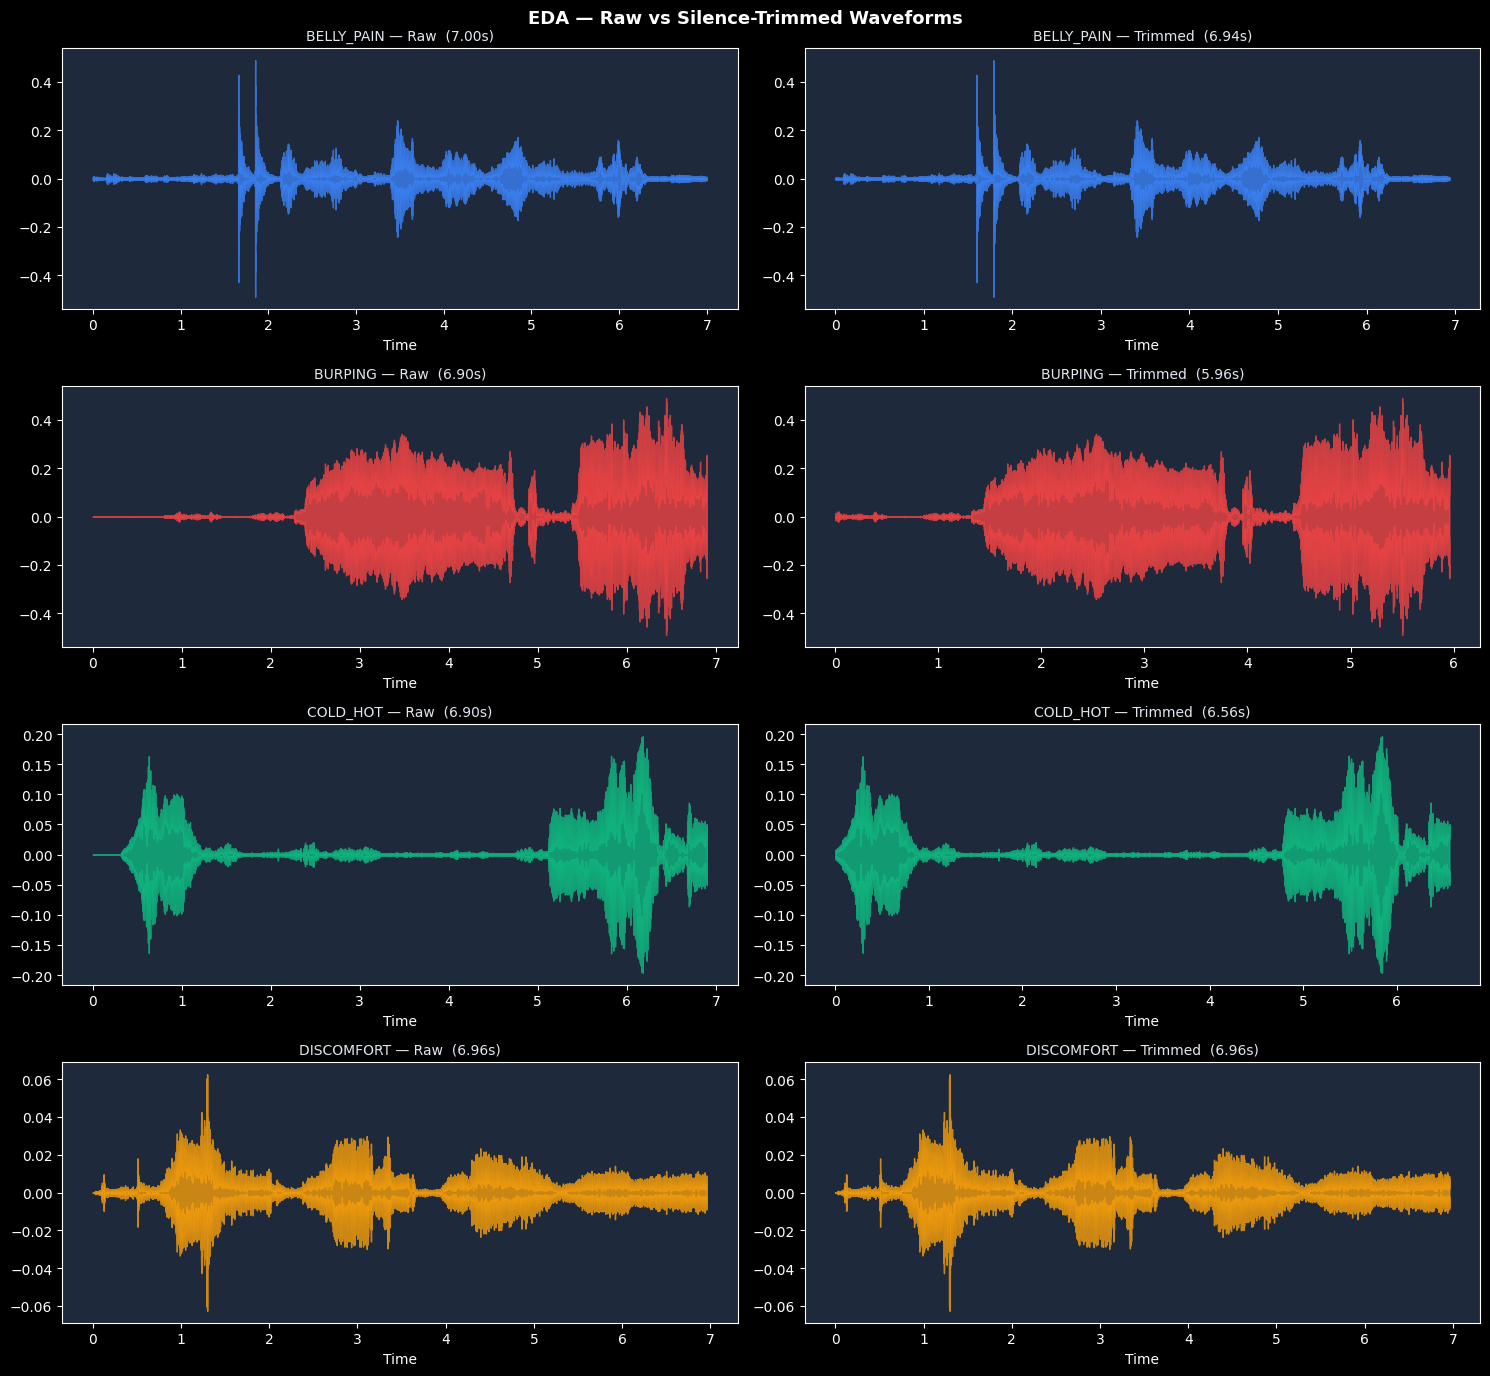

📝 Waveform observation points:
  → Left column : raw audio including silence at edges
  → Right column: after librosa.effects.trim(top_db=30)
  → Notice how trimmed version starts/ends at actual cry onset
  → Yeh trim features ko cleaner data deta hai


In [ ]:
# ════════════════════════════════════════════════════
# CELL 6 — Waveform visualization
# Problem tha: sirf ek sample per class, raw waveform
# Fix: raw vs trimmed side by side dikhao
# taaki visually samajh aaye ki trim ne kya kiya
# Aur 3 random samples per class — ek se judge mat karo
# ════════════════════════════════════════════════════

# kitne classes hain per plot — zyada hain toh top 4 lo
CLASSES_TO_PLOT = CLASS_FOLDERS[:4]

fig, axes = plt.subplots(len(CLASSES_TO_PLOT), 2,
                         figsize=(15, 3.5 * len(CLASSES_TO_PLOT)))
fig.suptitle('EDA — Raw vs Silence-Trimmed Waveforms',
             fontsize=13, fontweight='bold')

colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b']

for i, label in enumerate(CLASSES_TO_PLOT):
    # ek representative file pick karo — pehli wali nahi
    # kyunki pehli file outlier ho sakti hai
    # median duration ke closest file zyada representative hoti hai
    class_files = df_dur[df_dur['label'] == label]
    median_dur  = class_files['raw_duration'].median()

    # abs() difference se closest to median file dhundo
    best_idx  = (class_files['raw_duration'] - median_dur).abs().idxmin()
    best_file = class_files.loc[best_idx, 'filename']
    filepath  = df[df['filename'] == best_file]['filepath'].values[0]

    y_raw, sr  = librosa.load(filepath, sr=None)
    y_trim, _  = librosa.effects.trim(y_raw, top_db=30)

    # ── Left: Raw waveform ─────────────────────────
    librosa.display.waveshow(y_raw, sr=sr, ax=axes[i][0],
                             color=colors[i], alpha=0.8)
    axes[i][0].set_title(
        f'{label.upper()} — Raw  ({len(y_raw)/sr:.2f}s)',
        color='#e2e8f0', fontsize=10)
    axes[i][0].set_facecolor('#1e293b')

    # ── Right: Trimmed waveform ────────────────────
    librosa.display.waveshow(y_trim, sr=sr, ax=axes[i][1],
                             color=colors[i], alpha=0.8)
    axes[i][1].set_title(
        f'{label.upper()} — Trimmed  ({len(y_trim)/sr:.2f}s)',
        color='#e2e8f0', fontsize=10)
    axes[i][1].set_facecolor('#1e293b')

plt.tight_layout()
plt.savefig('waveform_raw_vs_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()

print("📝 Waveform observation points:")
print("  → Left column : raw audio including silence at edges")
print("  → Right column: after librosa.effects.trim(top_db=30)")
print("  → Notice how trimmed version starts/ends at actual cry onset")
print("  → Yeh trim features ko cleaner data deta hai")

In [ ]:
# ════════════════════════════════════════════════════
# CELL 7 — Build df_clean: sabhi EDA findings apply karo
#
# Remove karo:
#   1. Corrupt files (error_files se)
#   2. Files jo trimming ke baad bhi too short hain
#   3. Files jahan >80% silence hai — even after trimming
#      yeh files essentially noise hain, cry nahi
#
# df_clean hi aage feature extraction mein jayega
# ════════════════════════════════════════════════════

# corrupt filenames ka set
corrupt_names = {e['filename'] for e in error_files}

# too short after trim
short_names = set(df_dur[~df_dur['usable']]['filename'])

# mostly silence — 80% threshold
# 80% rakha 70% nahi — kyunki kuch classes mein files kam hain
# zyada aggressive filter karoge toh minority classes aur choti ho jayengi
mostly_silent = set(
    df_dur[df_dur['silence_percent'] > 80]['filename']
)

# combine all bad files
all_bad = corrupt_names | short_names | mostly_silent

df_clean = df[~df['filename'].isin(all_bad)].reset_index(drop=True)

# ── EDA Final Report ───────────────────────────────
print("╔══════════════════════════════════════════════════╗")
print("║         EDA COMPLETE — FINAL REPORT              ║")
print("╠══════════════════════════════════════════════════╣")
print(f"  Original files      : {len(df)}")
print(f"  Corrupt removed     : {len(corrupt_names)}")
print(f"  Too short removed   : {len(short_names)}")
print(f"  Mostly silent (>80%): {len(mostly_silent)}")
print(f"  ─────────────────────────────")
print(f"  Clean files remaining: {len(df_clean)}")

print(f"\n  Class distribution after cleaning:")
clean_counts = df_clean['label'].value_counts()
clean_total  = len(df_clean)
for label, cnt in clean_counts.items():
    pct = cnt / clean_total * 100
    print(f"    {label:<14}: {cnt:>4} files ({pct:.1f}%)")

new_ratio = clean_counts.max() / clean_counts.min()
print(f"\n  New imbalance ratio  : {new_ratio:.1f}:1")
print(f"\n  ⚠️  Imbalance still extreme — to be handled in model training")
print(f"  → Strategy: undersampling + SMOTE (next cells)")
print("╚══════════════════════════════════════════════════╝")

# save df_clean — aage ke cells mein yahi use hoga
print(f"\n✅ df_clean ready: {len(df_clean)} files")

╔══════════════════════════════════════════════════╗
║         EDA COMPLETE — FINAL REPORT              ║
╠══════════════════════════════════════════════════╣
  Original files      : 512
  Corrupt removed     : 0
  Too short removed   : 1
  Mostly silent (>80%): 1
  ─────────────────────────────
  Clean files remaining: 511

  Class distribution after cleaning:
    hungry        :  381 files (74.6%)
    discomfort    :   30 files (5.9%)
    tired         :   28 files (5.5%)
    scared        :   20 files (3.9%)
    burping       :   18 files (3.5%)
    belly_pain    :   16 files (3.1%)
    lonely        :   11 files (2.2%)
    cold_hot      :    7 files (1.4%)

  New imbalance ratio  : 54.4:1

  ⚠️  Imbalance still extreme — to be handled in model training
  → Strategy: undersampling + SMOTE (next cells)
╚══════════════════════════════════════════════════╝

✅ df_clean ready: 511 files


In [ ]:
# ════════════════════════════════════════════════════
# CELL 8 — Feature extraction function
#
# Pehle wali function mein kya galat tha:
# 1. Silence trim nahi tha — silent frames MFCC contaminate karte the
# 2. sr=22050 hardcoded tha CONFIG se nahi aata tha
# 3. Delta MFCC nahi tha — temporal dynamics miss ho rahe the
# 4. RMS energy nahi thi — loudness ek important feature hai cry mein
# ════════════════════════════════════════════════════

def extract_features(filepath):
    """
    Ek .wav file se acoustic features extract karta hai.
    Returns: 1D numpy array of 86 features

    Feature breakdown:
    - MFCC mean + std        : 20 + 20 = 40
    - Delta MFCC mean + std  : 20 + 20 = 40
    - ZCR mean + std         :  1 +  1 =  2
    - Spectral Centroid m+s  :  1 +  1 =  2
    - RMS Energy mean + std  :  1 +  1 =  2
    Total                    : 86 features
    """

    # sr=CONFIG['sample_rate'] — sabhi files 22050 Hz pe resample hongi
    # yeh isliye zaroori hai kyunki dataset mein mixed sampling rates hain
    # alag sr pe MFCC values directly comparable nahi hoti
    y, sr = librosa.load(filepath, sr=CONFIG['sample_rate'])

    # ── Step 1: Silence trim ──────────────────────
    # top_db=30 — 30 dB se neeche ki awaaz silence maano
    # EDA mein decide kiya tha yahi threshold use karenge
    # trim ke baad actual cry ka audio bachta hai — silence nahi
    y, _ = librosa.effects.trim(y, top_db=30)

    # ── Step 2: Normalize amplitude ───────────────
    # alag microphones pe alag amplitude hoti hai recordings ki
    # normalize karne se sabhi files ka amplitude -1 to 1 range mein aa jaata hai
    # agar normalize nahi kiya toh same cry alag loudness pe
    # alag MFCC values dega — model confuse hoga
    max_amp = np.max(np.abs(y))
    if max_amp > 0:
        # max_amp > 0 check isliye — bilkul silent file pe division by zero na ho
        y = y / max_amp

    features = []

    # ── Feature 1: MFCC ───────────────────────────
    # n_mfcc=20 — 20 coefficients, audio ML ka standard
    # shape: (20, time_frames) — 2D matrix
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CONFIG['n_mfcc'])

    # axis=1 — time axis ke across mean/std lo
    # har ek coefficient ka ek mean aur ek std → 20+20 = 40 features
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # ── Feature 2: Delta MFCC ─────────────────────
    # delta = MFCC ka time derivative
    # yeh batata hai ki sound KITNI TEZI SE change ho rahi hai
    # pain cry mein sudden sharp changes hote hain
    # sleepy cry mein gradual smooth changes hote hain
    # static MFCC yeh temporal information miss karta hai — delta pakadta hai
    delta_mfcc = librosa.feature.delta(mfcc)
    features.extend(np.mean(delta_mfcc, axis=1))
    features.extend(np.std(delta_mfcc, axis=1))

    # ── Feature 3: Zero Crossing Rate ─────────────
    # kitni baar signal positive se negative ya negative se positive jaata hai
    # high ZCR = noisy, high frequency cry (typically pain/discomfort)
    # low ZCR  = smooth, low frequency cry (typically tired/sleepy)
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # ── Feature 4: Spectral Centroid ──────────────
    # frequency spectrum ka "center of mass"
    # high centroid = zyada high frequency content = sharper, shriller cry
    # low centroid  = low frequency dominant = deeper, calmer cry
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(centroid))
    features.append(np.std(centroid))

    # ── Feature 5: RMS Energy ─────────────────────
    # root mean square energy = average loudness of the clip
    # pain cry mein typically high RMS bursts hote hain
    # tired cry mein RMS gradually decrease karta hai
    # pehle yeh feature missing tha — important signal tha miss ho raha tha
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    return np.array(features)


# ── Quick sanity test ──────────────────────────────
test_path = df_clean['filepath'].iloc[0]
test_vec  = extract_features(test_path)

print(f"✅ Feature extraction working")
print(f"   File     : {df_clean['filename'].iloc[0]}")
print(f"   Shape    : {test_vec.shape}  ← should be (86,)")
print(f"   No NaNs  : {not np.isnan(test_vec).any()}")

✅ Feature extraction working
   File     : 643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138514-1.0-m-72-bp.wav
   Shape    : (86,)  ← should be (86,)
   No NaNs  : True


In [ ]:
# ════════════════════════════════════════════════════
# CELL 9 — Loop through df_clean, extract features
#
# df_clean — EDA ke baad bana hua clean dataframe
# har file ke liye extract_features() call hoga
# saari feature vectors ek matrix mein join hongi
# CSV save hogi Drive pe — session reset pe dobara nahi chalana padega
# ════════════════════════════════════════════════════

all_features = []
all_labels   = []
failed_files = []

print(f"⏳ Extracting features from {len(df_clean)} files...")
print("   Estimated time: 3-6 minutes\n")

for idx, row in df_clean.iterrows():
    try:
        feat = extract_features(row['filepath'])

        # NaN check — kuch edge case files mein
        # after trim almost nothing bachta hai
        # us case mein MFCC NaN return kar sakta hai
        if np.isnan(feat).any():
            failed_files.append({
                'filename': row['filename'],
                'reason'  : 'NaN in features after extraction'
            })
            continue

        all_features.append(feat)
        all_labels.append(row['label'])

        if (len(all_features)) % 20 == 0:
            print(f"   {len(all_features)}/{len(df_clean)} done...")

    except Exception as e:
        failed_files.append({'filename': row['filename'], 'reason': str(e)})

print(f"\n✅ Successful : {len(all_features)} files")
print(f"❌ Failed     : {len(failed_files)} files")

# ── Convert to arrays ──────────────────────────────
X = np.array(all_features)   # shape: (n_files, 86)
y_raw = np.array(all_labels)

print(f"\n📐 Feature matrix shape : {X.shape}")
print(f"   Rows (files)        : {X.shape[0]}")
print(f"   Columns (features)  : {X.shape[1]}")

# ── Build column names ─────────────────────────────
mfcc_mean_cols   = [f'mfcc_mean_{i}'        for i in range(20)]
mfcc_std_cols    = [f'mfcc_std_{i}'         for i in range(20)]
delta_mean_cols  = [f'delta_mfcc_mean_{i}'  for i in range(20)]
delta_std_cols   = [f'delta_mfcc_std_{i}'   for i in range(20)]
other_cols       = ['zcr_mean', 'zcr_std',
                    'centroid_mean', 'centroid_std',
                    'rms_mean', 'rms_std']

col_names = (mfcc_mean_cols + mfcc_std_cols +
             delta_mean_cols + delta_std_cols +
             other_cols)

# col_names ki length feature vector ki length ke barabar honi chahiye
assert len(col_names) == X.shape[1], \
    f"Mismatch: {len(col_names)} names vs {X.shape[1]} features"

df_features = pd.DataFrame(X, columns=col_names)
df_features['label'] = y_raw

# ── Save to Drive immediately ──────────────────────
# immediately isliye save karo — colab session timeout hoti hai
# agar save nahi kiya toh 5 min ka kaam dobara karna padega
df_features.to_csv(CONFIG['csv_save_path'], index=False)

print(f"\n💾 CSV saved: {CONFIG['csv_save_path']}")
print(f"   Rows: {len(df_features)}  Columns: {len(df_features.columns)}")
print(f"\nLabel distribution in saved CSV:")
print(df_features['label'].value_counts().to_string())

⏳ Extracting features from 511 files...
   Estimated time: 3-6 minutes

   20/511 done...
   40/511 done...
   60/511 done...
   80/511 done...
   100/511 done...
   120/511 done...
   140/511 done...
   160/511 done...
   180/511 done...
   200/511 done...
   220/511 done...
   240/511 done...
   260/511 done...
   280/511 done...
   300/511 done...
   320/511 done...
   340/511 done...
   360/511 done...
   380/511 done...
   400/511 done...
   420/511 done...
   440/511 done...
   460/511 done...
   480/511 done...
   500/511 done...

✅ Successful : 511 files
❌ Failed     : 0 files

📐 Feature matrix shape : (511, 86)
   Rows (files)        : 511
   Columns (features)  : 86

💾 CSV saved: /content/drive/MyDrive/Baby Cry Sence Dataset/features_matrix.csv
   Rows: 511  Columns: 87

Label distribution in saved CSV:
label
hungry        381
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7


In [ ]:
# ════════════════════════════════════════════════════
# CELL 10 — Undersample 'hungry' class
#
# Problem: hungry = 74.6% (54:1 ratio)
# class_weight='balanced' + SMOTE akele kaafi nahi 54:1 pe
#
# Strategy:
# hungry ko undersample karo — 382 → ~100 files
# kyun 100? second largest class (discomfort) ~30 files hai
# hungry ko 3-4x of second largest pe laana reasonable hai
# zyada aggressive undersampling se hungry class ka information loss hoga
# kam aggressive kiya toh 54:1 pe SMOTE bhi struggle karega
#
# NOTE: Undersampling pehle, split baad mein
# kyunki agar split pehle kiya toh test set mein bhi
# hungry ke zyada samples rahenge — evaluation biased hoga
# ════════════════════════════════════════════════════

# load karo CSV — session reset case ke liye
# agar pehle se memory mein df_features hai toh yeh line skip kar sakte ho
df_ml = pd.read_csv(CONFIG['csv_save_path'])

print("Before undersampling:")
print(df_ml['label'].value_counts().to_string())
print(f"Total: {len(df_ml)}")

# ── Undersample hungry ─────────────────────────────
HUNGRY_LIMIT = 100
# 100 kyun:
# - second largest class ~30 files hai
# - 100 = roughly 3x of that — model ko enough hungry examples milenge
# - 382 se 100 karna drastic lagta hai but 54:1 ratio ke saath zaroori hai
# - 100 pe bhi hungry still majority rahega — just not overwhelmingly so

hungry_df     = df_ml[df_ml['label'] == 'hungry'].sample(
                    n=HUNGRY_LIMIT, random_state=42)
# random_state=42 — reproducibility ke liye
# same seed = same 100 samples har baar pick honge

non_hungry_df = df_ml[df_ml['label'] != 'hungry']

# dono ko combine karo
df_balanced = pd.concat([hungry_df, non_hungry_df]).reset_index(drop=True)

# ── Shuffle — important ────────────────────────────
# concat ke baad hungry files upar aur baaki neeche hoti hain
# agar shuffle nahi kiya toh train-test split mein
# pehle sab hungry samples train mein jaayenge
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter undersampling:")
print(df_balanced['label'].value_counts().to_string())
print(f"Total: {len(df_balanced)}")

new_ratio = (df_balanced['label'].value_counts().max() /
             df_balanced['label'].value_counts().min())
print(f"\nNew imbalance ratio: {new_ratio:.1f}:1")
print("   (Still imbalanced but SMOTE inside pipeline handle karega)")

Before undersampling:
label
hungry        381
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7
Total: 511

After undersampling:
label
hungry        100
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7
Total: 230

New imbalance ratio: 14.3:1
   (Still imbalanced but SMOTE inside pipeline handle karega)


In [ ]:
# ════════════════════════════════════════════════════
# CELL 11 — Encode labels + split + scale
#
# Critical fix: pehle scaler X pe fit kiya tha — DATA LEAKAGE
# Sahi order:
#   1. Split karo
#   2. Scaler sirf X_train pe fit karo
#   3. X_test pe sirf transform karo — fit nahi
#
# Agar scaler puri X pe fit ho toh test set ke
# statistics training mein leak ho jaate hain
# model notebook pe achha lagta hai, real world pe fail karta hai
# ════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler

# ── Separate features and labels ───────────────────
X_full = df_balanced.drop(columns=['label']).values
y_full = df_balanced['label'].values

# ── Label encoding ─────────────────────────────────
# RandomForest aur SVM string labels nahi lete — numbers chahiye
# LabelEncoder alphabetical order mein assign karta hai:
# belly_pain→0, burping→1, cold_hot→2, discomfort→3 ...
le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

print("Label encoding:")
for name, code in zip(le.classes_, range(len(le.classes_))):
    cnt = (y_encoded == code).sum()
    print(f"  {name:<14} → {code}  ({cnt} samples)")

# ── Stratified train-test split ────────────────────
# stratify=y_encoded — ZAROORI
# bina stratify ke test set mein cold_hot ke 0 samples aa sakte hain
# stratify ensure karta hai: har class ka same proportion train aur test dono mein
# test_size=0.2 — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # ← yeh line miss karna common mistake hai
)

print(f"\nSplit result:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Test : {X_test.shape[0]} samples")

print("\nTrain class distribution:")
for code, name in enumerate(le.classes_):
    print(f"  {name:<14}: {(y_train == code).sum()}")

print("\nTest class distribution:")
for code, name in enumerate(le.classes_):
    print(f"  {name:<14}: {(y_test == code).sum()}")

# ── Scale features ─────────────────────────────────
scaler = StandardScaler()

# fit_transform — SIRF X_train pe
# scaler X_train ka mean aur std seekhta hai
# yahi statistics X_test pe bhi apply hongi
X_train_scaled = scaler.fit_transform(X_train)

# transform only — fit nahi
# X_test ka mean/std scaler ko pata nahi — as it should be
# real world mein bhi naya data aayega jiska distribution unknown hoga
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Scaling done")
print(f"   Scaler fit on TRAIN only — no data leakage")
print(f"   X_train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"   X_test  mean (won't be 0)  : {X_test_scaled.mean():.4f}")

Label encoding:
  belly_pain     → 0  (16 samples)
  burping        → 1  (18 samples)
  cold_hot       → 2  (7 samples)
  discomfort     → 3  (30 samples)
  hungry         → 4  (100 samples)
  lonely         → 5  (11 samples)
  scared         → 6  (20 samples)
  tired          → 7  (28 samples)

Split result:
  Train: 184 samples
  Test : 46 samples

Train class distribution:
  belly_pain    : 13
  burping       : 14
  cold_hot      : 6
  discomfort    : 24
  hungry        : 80
  lonely        : 9
  scared        : 16
  tired         : 22

Test class distribution:
  belly_pain    : 3
  burping       : 4
  cold_hot      : 1
  discomfort    : 6
  hungry        : 20
  lonely        : 2
  scared        : 4
  tired         : 6

✅ Scaling done
   Scaler fit on TRAIN only — no data leakage
   X_train mean (should be ~0): 0.0000
   X_test  mean (won't be 0)  : 0.1095


⏳ Running 5-fold Stratified CV with SMOTE + Random Forest...
   (Takes ~2-3 minutes)

CV F1-Macro scores per fold: [0.359 0.256 0.304 0.601 0.345]
Mean  : 0.373
Std   : 0.120

⏳ Training final RF model on full training set...

══════════════════════════════════════════════════
RANDOM FOREST — TEST SET RESULTS
══════════════════════════════════════════════════
Accuracy : 45.65%
F1 Macro : 27.65%

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00         3
     burping       1.00      0.25      0.40         4
    cold_hot       0.00      0.00      0.00         1
  discomfort       0.00      0.00      0.00         6
      hungry       0.52      0.75      0.61        20
      lonely       0.00      0.00      0.00         2
      scared       1.00      1.00      1.00         4
       tired       0.25      0.17      0.20         6

    accuracy                           0.46        46
   macro avg       0.35      0.27   

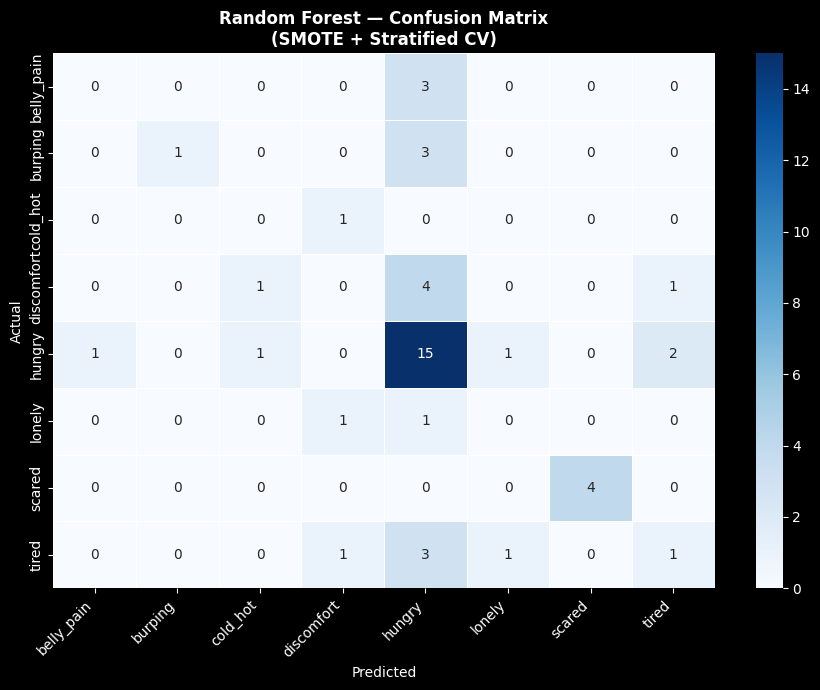


⚠️  Note: Classes with very few test samples (cold_hot, lonely)
   ke results statistically reliable nahi hain — data ki kami hai


In [ ]:
# ════════════════════════════════════════════════════
# CELL 12 — Random Forest with SMOTE inside pipeline
#
# SMOTE ko pipeline ke andar rakhna ZAROORI hai
# agar SMOTE pehle apply kiya phir CV split kiya
# toh synthetic samples train aur test dono mein ja sakte hain
# — yeh data leakage hai
#
# Pipeline ka kaam:
# har CV fold mein:
#   Step 1: us fold ke X_train pe SMOTE chalao
#   Step 2: SMOTE wale data pe RF train karo
#   Step 3: ORIGINAL X_test fold pe evaluate karo
#           (SMOTE wale synthetic data pe nahi)
# ════════════════════════════════════════════════════

# imbalanced-learn install — SMOTE yahan se aata hai
!pip install imbalanced-learn -q

from imblearn.pipeline       import Pipeline
from imblearn.over_sampling  import SMOTE
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     accuracy_score, f1_score)

# ── SMOTE configuration ────────────────────────────
# k_neighbors=3 — kitne nearest neighbors se synthetic sample banao
# default 5 hai, lekin kuch minority classes mein sirf 5-7 samples hain
# k_neighbors unse kam hona chahiye warna error
# safe value = min(class_count) - 1, lekin 3 rakha cautiously
smote = SMOTE(k_neighbors=3, random_state=42)

# ── Random Forest configuration ────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    # 300 trees — zyada trees = more stable predictions
    # 200 se 300 kiya kyunki 8 classes hain — complex problem
    class_weight='balanced',
    # class_weight bhi rakha alongside SMOTE
    # SMOTE oversampling karta hai minority ko
    # class_weight additionally unhe zyada importance deta hai
    # dono saath = better minority class handling
    max_depth=None,
    # None = trees fully grow karein
    # deep trees complex patterns pakad lete hain
    # RF mein overfitting kam hoti hai bagging ki wajah se
    min_samples_leaf=2,
    # leaf node mein kam se kam 2 samples hone chahiye
    # 1 rakha toh single noisy sample pe leaf ban jaati hai
    random_state=42,
    n_jobs=-1
)

# ── Pipeline: SMOTE → RF ───────────────────────────
# imbalanced-learn ka Pipeline use kar rahe hain
# sklearn ka Pipeline SMOTE support nahi karta properly
rf_pipeline = Pipeline([
    ('smote', smote),
    ('rf',    rf)
])

# ── Stratified K-Fold ──────────────────────────────
# n_splits=5 — 5 fold CV
# shuffle=True — data shuffle karo pehle split se
# bina shuffle ke consecutive same-class samples ek fold mein ja sakte hain
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("⏳ Running 5-fold Stratified CV with SMOTE + Random Forest...")
print("   (Takes ~2-3 minutes)\n")

# scoring='f1_macro' — PRIMARY METRIC
# accuracy nahi kyunki 54:1 imbalance mein accuracy misleading hai
# macro = har class ka F1 equally weigh karo
# weighted nahi — weighted majority class ko zyada weight deta hai
cv_scores_rf = cross_val_score(
    rf_pipeline,
    X_train_scaled, y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(f"CV F1-Macro scores per fold: {cv_scores_rf.round(3)}")
print(f"Mean  : {cv_scores_rf.mean():.3f}")
print(f"Std   : {cv_scores_rf.std():.3f}")
# std dekho — agar zyada high hai (>0.1) toh model inconsistent hai
# kuch folds pe achha kuch pe bura — class imbalance ki wajah se

# ── Final train on full training set ──────────────
print("\n⏳ Training final RF model on full training set...")
rf_pipeline.fit(X_train_scaled, y_train)

# ── Evaluate on test set ───────────────────────────
y_pred_rf = rf_pipeline.predict(X_test_scaled)

print("\n" + "═"*50)
print("RANDOM FOREST — TEST SET RESULTS")
print("═"*50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1 Macro : {f1_score(y_test, y_pred_rf, average='macro')*100:.2f}%")
# F1 Macro — primary metric dekhna hai yeh
# accuracy dekhna hai but rely mat karna iske pe

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=le.classes_,
                             zero_division=0))
# zero_division=0 — agar koi class test set mein predict hi nahi hui
# toh division by zero na ho — 0 return karo

# ── Confusion Matrix ───────────────────────────────
plt.figure(figsize=(9, 7))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Random Forest — Confusion Matrix\n(SMOTE + Stratified CV)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️  Note: Classes with very few test samples (cold_hot, lonely)")
print("   ke results statistically reliable nahi hain — data ki kami hai")

⏳ Running 5-fold Stratified CV with SMOTE + SVM...
   (SVM CV takes longer than RF — ~5-8 minutes)

CV F1-Macro scores per fold: [0.425 0.276 0.33  0.446 0.24 ]
Mean : 0.343
Std  : 0.081

⏳ Training final SVM model on full training set...

══════════════════════════════════════════════════
SVM (RBF) — TEST SET RESULTS
══════════════════════════════════════════════════
Accuracy : 47.83%
F1 Macro : 34.52%

Classification Report:
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00         3
     burping       1.00      0.25      0.40         4
    cold_hot       0.00      0.00      0.00         1
  discomfort       0.00      0.00      0.00         6
      hungry       0.50      0.80      0.62        20
      lonely       1.00      0.50      0.67         2
      scared       1.00      0.75      0.86         4
       tired       0.33      0.17      0.22         6

    accuracy                           0.48        46
   macro avg       0.48    

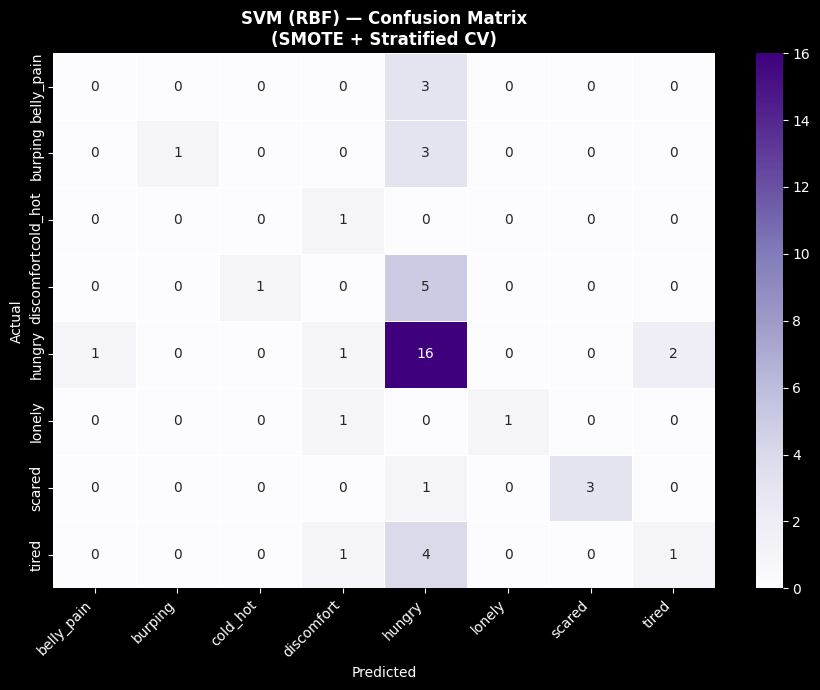

In [ ]:
# ════════════════════════════════════════════════════
# CELL 13 — SVM with same SMOTE pipeline
#
# SVM ke liye scaling already done hai (Cell 11)
# SVM distance-based algorithm hai — scaling critical hai
# RF ke liye scaling less critical thi lekin SVM ke liye must hai
# ════════════════════════════════════════════════════

from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    # rbf = Radial Basis Function kernel
    # data ko higher dimension mein project karta hai
    # jahan linear boundary se classes separate ho sakti hain
    # infant cry ka data linearly separable nahi hai — isliye rbf
    C=10,
    # C = regularization parameter
    # high C = strict boundary, low training error, overfitting risk
    # low C  = soft boundary, some misclassification allowed, better generalization
    # 10 reasonable starting point hai — hyperparameter tuning mein refine karenge
    gamma='scale',
    # 'scale' = 1 / (n_features * X.var()) automatically calculate karta hai
    # manually set karne se galti ki chance zyada — scale safe choice hai
    class_weight='balanced',
    # SVM mein bhi class_weight rakha — SMOTE ke saath double protection
    probability=False,
    # probability=True karna SVM ko slow karta hai (Platt scaling)
    # abhi sirf predictions chahiye — probability baad mein enable karna
    random_state=42
)

svm_pipeline = Pipeline([
    ('smote', SMOTE(k_neighbors=3, random_state=42)),
    ('svm',   svm)
])

print("⏳ Running 5-fold Stratified CV with SMOTE + SVM...")
print("   (SVM CV takes longer than RF — ~5-8 minutes)\n")

cv_scores_svm = cross_val_score(
    svm_pipeline,
    X_train_scaled, y_train,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(f"CV F1-Macro scores per fold: {cv_scores_svm.round(3)}")
print(f"Mean : {cv_scores_svm.mean():.3f}")
print(f"Std  : {cv_scores_svm.std():.3f}")

# ── Final train ────────────────────────────────────
print("\n⏳ Training final SVM model on full training set...")
svm_pipeline.fit(X_train_scaled, y_train)

y_pred_svm = svm_pipeline.predict(X_test_scaled)

print("\n" + "═"*50)
print("SVM (RBF) — TEST SET RESULTS")
print("═"*50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print(f"F1 Macro : {f1_score(y_test, y_pred_svm, average='macro')*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=le.classes_,
                             zero_division=0))

plt.figure(figsize=(9, 7))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('SVM (RBF) — Confusion Matrix\n(SMOTE + Stratified CV)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ════════════════════════════════════════════════════
# CELL 14 — Compare models + Dummy baseline
#
# Pehle baseline comparison missing tha
# DummyClassifier batata hai ki kya tera model
# actually kuch seekha ya sirf majority predict kar raha hai
# agar tera RF/SVM dummy se zyada achha nahi — model useless hai
# ════════════════════════════════════════════════════

from sklearn.dummy   import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# ── Dummy baseline ─────────────────────────────────
# strategy='most_frequent' — hamesha majority class predict karo
# yeh worst case baseline hai
# agar tera model is se bhi bura ho — serious problem hai
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

# ── Metrics helper function ─────────────────────────
def get_metrics(y_true, y_pred, name):
    return {
        'Model'        : name,
        'Accuracy %'   : round(accuracy_score(y_true, y_pred) * 100, 2),
        'F1 Macro %'   : round(f1_score(y_true, y_pred,
                               average='macro', zero_division=0) * 100, 2),
        'F1 Weighted %': round(f1_score(y_true, y_pred,
                               average='weighted', zero_division=0) * 100, 2),
        'Precision %'  : round(precision_score(y_true, y_pred,
                               average='macro', zero_division=0) * 100, 2),
        'Recall %'     : round(recall_score(y_true, y_pred,
                               average='macro', zero_division=0) * 100, 2),
    }

results = [
    get_metrics(y_test, y_pred_dummy, 'Dummy (Baseline)'),
    get_metrics(y_test, y_pred_rf,    'Random Forest'),
    get_metrics(y_test, y_pred_svm,   'SVM (RBF)'),
]

df_results = pd.DataFrame(results).set_index('Model')

print("╔══════════════════════════════════════════════════╗")
print("║           MODEL COMPARISON REPORT                ║")
print("╠══════════════════════════════════════════════════╣")
print(df_results.to_string())
print("╚══════════════════════════════════════════════════╝")

# ── CV comparison ──────────────────────────────────
print("\n📊 Cross Validation F1-Macro (Training Set):")
print(f"   Random Forest : {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")
print(f"   SVM           : {cv_scores_svm.mean():.3f} ± {cv_scores_svm.std():.3f}")

# ── Winner ─────────────────────────────────────────
# F1 macro se winner decide karo — accuracy se nahi
best = df_results['F1 Macro %'].idxmax()
print(f"\n🏆 Better model (F1 Macro): {best}")

# ── Sanity check against dummy ─────────────────────
rf_f1    = df_results.loc['Random Forest',    'F1 Macro %']
svm_f1   = df_results.loc['SVM (RBF)',        'F1 Macro %']
dummy_f1 = df_results.loc['Dummy (Baseline)', 'F1 Macro %']

print(f"\n🔍 Sanity Check vs Dummy Baseline:")
print(f"   Dummy F1 Macro  : {dummy_f1}%")
print(f"   RF F1 Macro     : {rf_f1}%  "
      f"({'✅ Better' if rf_f1 > dummy_f1 else '❌ Worse than dummy'})")
print(f"   SVM F1 Macro    : {svm_f1}%  "
      f"({'✅ Better' if svm_f1 > dummy_f1 else '❌ Worse than dummy'})")

╔══════════════════════════════════════════════════╗
║           MODEL COMPARISON REPORT                ║
╠══════════════════════════════════════════════════╣
                  Accuracy %  F1 Macro %  F1 Weighted %  Precision %  Recall %
Model                                                                         
Dummy (Baseline)       43.48        7.58          26.35         5.43     12.50
Random Forest          45.65       27.65          41.40        34.59     27.08
SVM (RBF)              47.83       34.52          43.48        47.92     30.83
╚══════════════════════════════════════════════════╝

📊 Cross Validation F1-Macro (Training Set):
   Random Forest : 0.373 ± 0.120
   SVM           : 0.343 ± 0.081

🏆 Better model (F1 Macro): SVM (RBF)

🔍 Sanity Check vs Dummy Baseline:
   Dummy F1 Macro  : 7.58%
   RF F1 Macro     : 27.65%  (✅ Better)
   SVM F1 Macro    : 34.52%  (✅ Better)


In [ ]:
# ════════════════════════════════════════════════════
# CELL 15 — Save models, scaler, encoder
#
# Timestamp add kiya — version tracking ke liye
# pehle sirf random_forest.pkl tha — overwrite hone ka risk tha
# ════════════════════════════════════════════════════

import pickle
from datetime import datetime

os.makedirs(CONFIG['models_dir'], exist_ok=True)

# timestamp — kal dobara train kiya toh purana model overwrite na ho
ts = datetime.now().strftime('%Y%m%d_%H%M')

to_save = {
    f'rf_pipeline_{ts}.pkl'     : rf_pipeline,
    # full pipeline save karo — smote + model dono
    # inference mein sirf raw features do — pipeline handle kar legi
    f'svm_pipeline_{ts}.pkl'    : svm_pipeline,
    f'scaler_{ts}.pkl'          : scaler,
    # scaler zaroori hai inference ke liye
    # naya audio file ka feature vector scale karna padega
    # usi scaler se jo training pe fit hua tha
    f'label_encoder_{ts}.pkl'   : le,
    # le.inverse_transform() prediction number ko class name mein convert karta hai
    f'feature_cols_{ts}.pkl'    : col_names,
    # column names save karo taaki future mein feature order confirm kar sakein
}

for fname, obj in to_save.items():
    path = CONFIG['models_dir'] + fname
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved: {fname}")

# ── Save results CSV ───────────────────────────────
results_path = CONFIG['models_dir'] + f'results_{ts}.csv'
df_results.to_csv(results_path)
print(f"✅ Saved: results_{ts}.csv")

print(f"\n📁 All files saved to: {CONFIG['models_dir']}")

✅ Saved: rf_pipeline_20260713_1119.pkl
✅ Saved: svm_pipeline_20260713_1119.pkl
✅ Saved: scaler_20260713_1119.pkl
✅ Saved: label_encoder_20260713_1119.pkl
✅ Saved: feature_cols_20260713_1119.pkl
✅ Saved: results_20260713_1119.csv

📁 All files saved to: /content/drive/MyDrive/Baby Cry Sence Dataset/models/
